In [ ]:
import torch
import torch.optim as optim

from utils import InMemDataLoader, draw_images, get_device
from classifier_common import (
    Model,
    download_data,
    prepare_data,
    draw_images_with_score,
    load_images,
    train,
)

In [ ]:
device = get_device()
print(device)

In [ ]:
IMG_WIDTH = 48
DATASET_NAMES = (
    "teddy-bear",
    "bird",
    "rabbit",
    "cat",
    "owl",
    "squiggle",
    "pond",
    "cow",
)

download_data(DATASET_NAMES)

In [ ]:
BATCH_SIZE = 128
NO_OF_BATCHES = 700

all_data = prepare_data(DATASET_NAMES, BATCH_SIZE, NO_OF_BATCHES)
train_data, valid_data, test_data = torch.utils.data.random_split(
    all_data, [0.6, 0.2, 0.2]
)

data_loader = {
    "train": InMemDataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True),
    "valid": InMemDataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False),
    "test": InMemDataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False),
}

In [ ]:
data_loader["train"].to(device)
data_loader["valid"].to(device)
data_loader["test"].to(device)

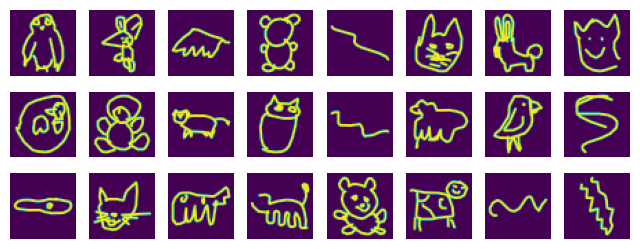

In [7]:
draw_images([train_data[i][0] for i in range(50)], rows=3, cols=8)

In [8]:
model = Model(out_dim=8).to(device)

In [9]:
lr = 0.0005
epochs = 5000
weight_decay = 0.0001

opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [ ]:
train(model=model, no_of_epochs=epochs, data_loaders=data_loader, opt=opt)

In [ ]:
torch.save(model.state_dict(), "models/classifier_d8.model")

In [ ]:
bear_imgs = load_images("datasets/teddy-bear.bin", 5000)
bad_img, good_img = [], []

model.eval()
with torch.no_grad():
    for img in bear_imgs:
        quality = (
            model(
                torch.tensor(img).float().reshape(1, 1, IMG_WIDTH, IMG_WIDTH).to(device)
            )
            .cpu()[0][0]
            .item()
        )
        if quality < 0.9:
            bad_img.append((img, quality))
        else:
            good_img.append((img, quality))

print(
    f"Filtered out {len(bad_img)} / {len(bear_imgs)} = {100 * len(bad_img) / len(bear_imgs):.2f}% of data set "
)

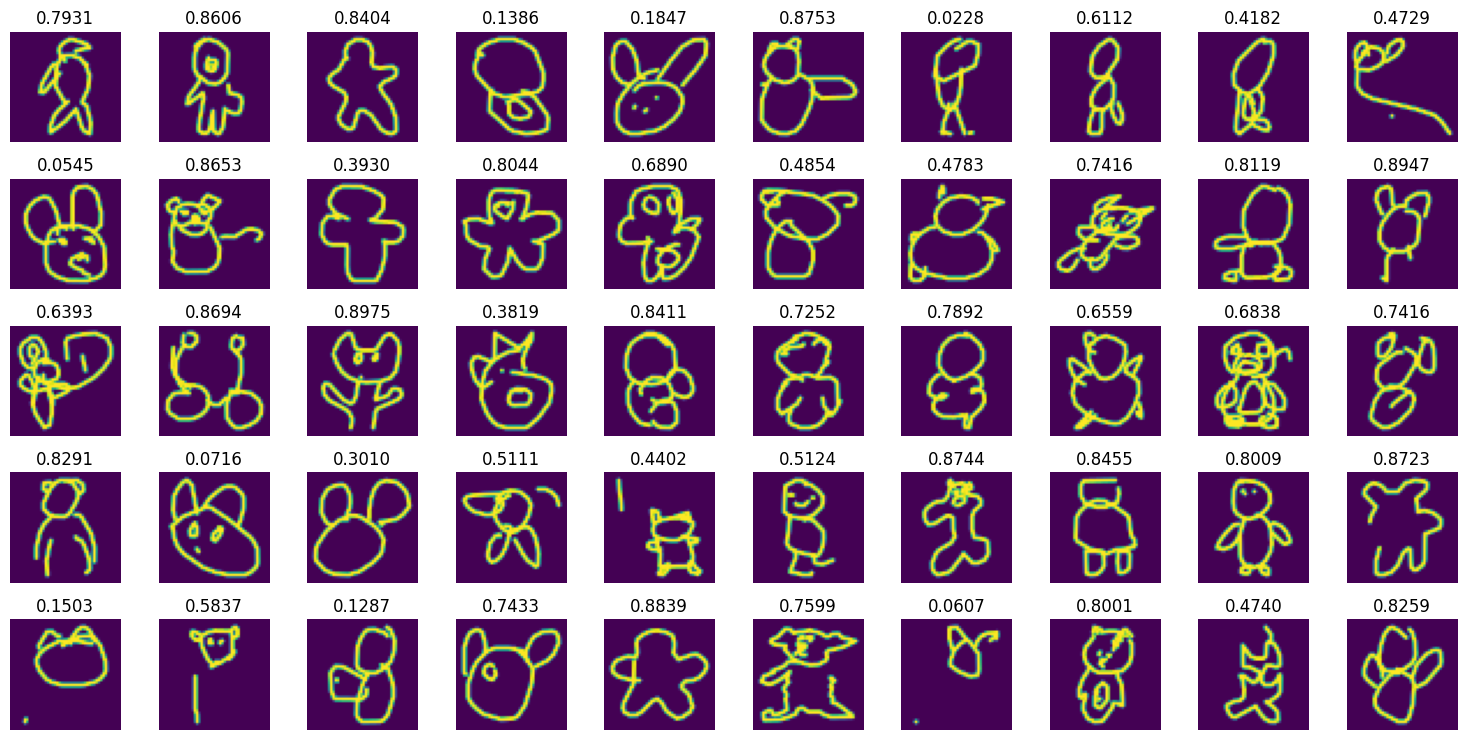

In [15]:
draw_images_with_score(bad_img)

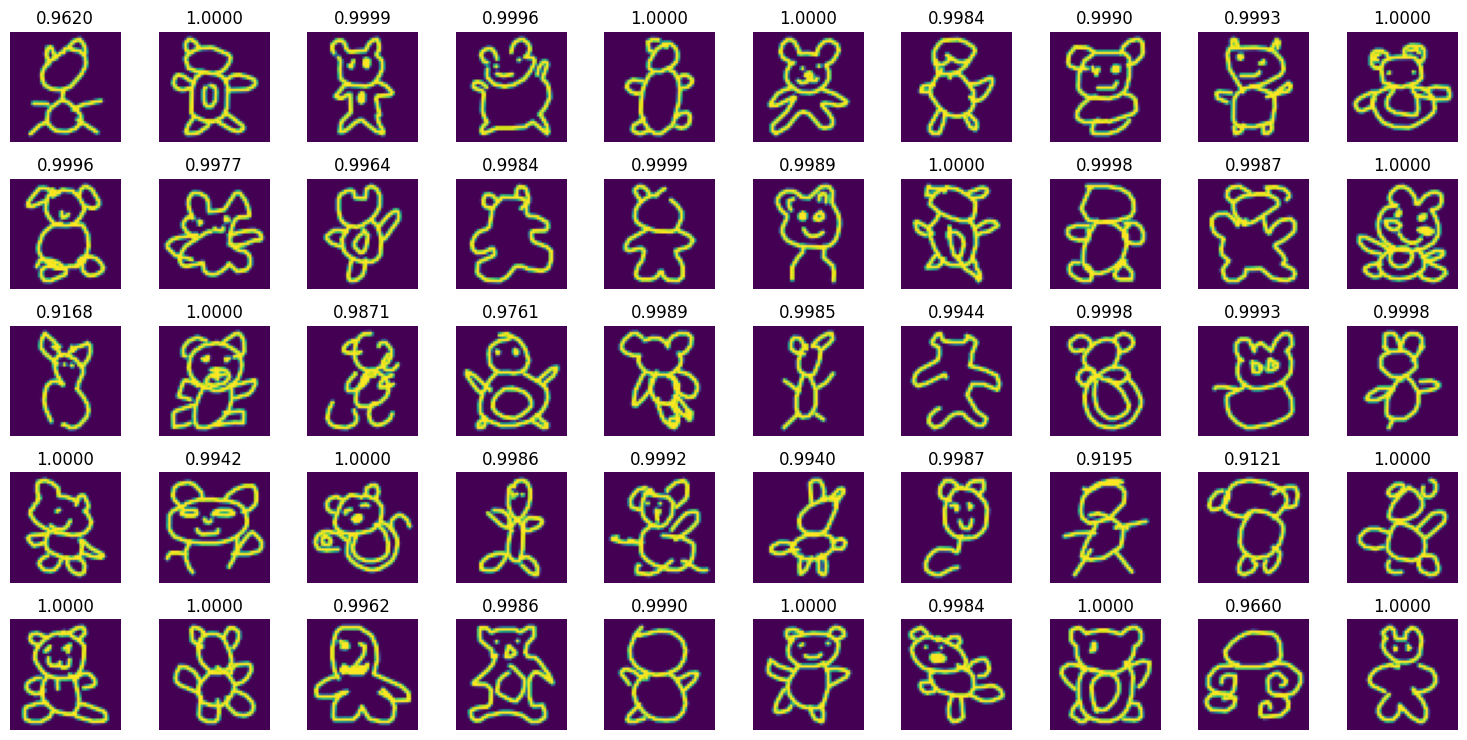

In [16]:
draw_images_with_score(good_img)